In [1]:
import xir
import vart
import numpy as np

graph = xir.Graph.deserialize("CNN_kv260.xmodel")



subgraphs = graph.get_root_subgraph().toposort_child_subgraph()
dpu_subgraph = [s for s in subgraphs if s.has_attr("device") and s.get_attr("device").upper() == "DPU"][0]
runner = vart.Runner.create_runner(dpu_subgraph, "run")

input_scale = 2 ** runner.get_input_tensors()[0].get_attr("fix_point")
output_scale = 2 ** runner.get_output_tensors()[0].get_attr("fix_point")

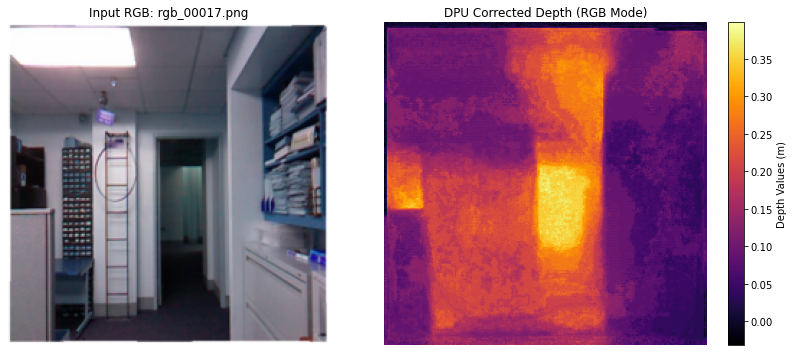

In [43]:
# =====================================================================
# INFERENCE MATÉRIELLE DPU REALIGNÉE (RGB STRICT)
# =====================================================================
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from random import randint

# 1. Échelles dynamiques lues depuis le DPU (Entrée: 2^6=64, Sortie: 2^7=128)
input_scale = 2 ** runner.get_input_tensors()[0].get_attr("fix_point")
output_scale = 2 ** runner.get_output_tensors()[0].get_attr("fix_point")

# 2. Sélection de l'image
random_idx = randint(0, len(rgb_files) - 1)
rgb_path = rgb_files[random_idx]

# 3. Pré-traitement STRICT RGB
raw_img = Image.open(rgb_path).convert('RGB')
raw_img = raw_img.resize((224, 224), Image.BILINEAR)

# Image float [0, 1] pour l'affichage et la quantification
img_float = np.array(raw_img, dtype=np.float32) / 255.0

# Buffers matériels
dpu_input_buffer = np.zeros([1, 224, 224, 3], dtype=np.int8)
dpu_output_buffer = np.zeros([1, 224, 224, 1], dtype=np.int8)

# On pousse le RGB STRICT multiplié par 2^6 (64)
dpu_input_buffer[0] = (img_float * input_scale).astype(np.int8)

# 4. Exécution DPU
job_id = runner.execute_async(dpu_input_buffer, dpu_output_buffer)
runner.wait(job_id)

# 5. Dé-quantification par 2^7 (128)
predicted_depth = dpu_output_buffer[0].astype(np.float32) / output_scale
predicted_depth = predicted_depth.squeeze()

# 6. Affichage
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img_float) # Affichage RGB Direct
axes[0].set_title(f"Input RGB: {os.path.basename(rgb_path)}")
axes[0].axis('off')

depth_plot = axes[1].imshow(predicted_depth, cmap='inferno')
axes[1].set_title("DPU Corrected Depth (RGB Mode)")
axes[1].axis('off')
fig.colorbar(depth_plot, ax=axes[1], orientation='vertical', label='Depth Values (m)')

plt.tight_layout()
plt.show()

In [2]:
def preprocess_rgb(file_path):
    rgb_data = Image.open(file_path).convert('RGB')
    # Fixed for older Pillow versions: replaced Image.Resampling.BILINEAR with Image.BILINEAR
    rgb_data = rgb_data.resize((224, 224), Image.BILINEAR)
    
    rgb_data = np.array(rgb_data, dtype=np.float32) / 255.0
    return rgb_data

def preprocess_dep(file_path):
    dep_data = Image.open(file_path)
    # Fixed here as well
    dep_data = dep_data.resize((224, 224), Image.BILINEAR)
    
    dep_data = np.array(dep_data, dtype=np.float32)
    
    dep_data = (dep_data * 10) / (2**16 - 1)
    dep_data = np.clip(dep_data, 0.7, 10.0)
    dep_data = (dep_data - 0.7) / (10.0 - 0.7)
    
    return np.expand_dims(dep_data, axis=-1)

Fichiers trouvés : 21 paires rgb/depth


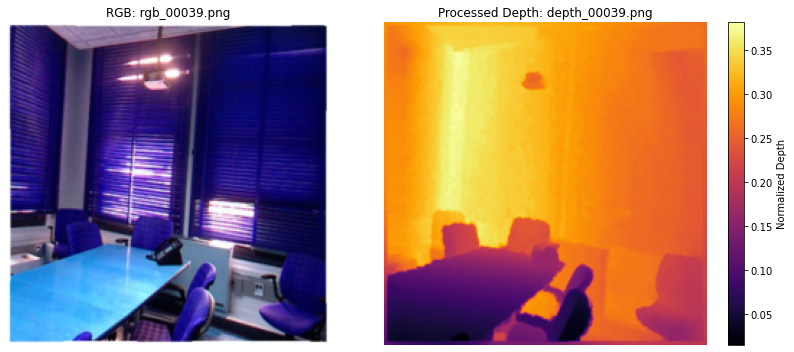

In [3]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from random import randint

image_dir = "images"

# Fixed the typo here: changed "depth_.png" to "depth_*.png"
rgb_files = sorted(glob.glob(os.path.join(image_dir, "**", "rgb_*.png"), recursive=True))
dep_files = sorted(glob.glob(os.path.join(image_dir, "**", "depth_*.png"), recursive=True))

assert len(rgb_files) == len(dep_files) and len(rgb_files) > 0, (
    f"Mismatch or empty: {len(rgb_files)} rgb vs {len(dep_files)} depth"
)
print(f"Fichiers trouvés : {len(rgb_files)} paires rgb/depth")

random_idx = randint(0, len(rgb_files)-1)

rgb_data = preprocess_rgb(rgb_files[random_idx])
dep_data = preprocess_dep(dep_files[random_idx])

# 3. Plotting with pyplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Display RGB
axes[0].imshow(rgb_data)
axes[0].set_title(f"RGB: {os.path.basename(rgb_files[random_idx])}")
axes[0].axis('off')

# Display Depth (using 'inferno' or 'plasma' colormap works great for depth maps)
depth_plot = axes[1].imshow(dep_data, cmap='inferno')
axes[1].set_title(f"Processed Depth: {os.path.basename(dep_files[random_idx])}")
axes[1].axis('off')

# Add a colorbar to see the normalized 0-1 scale
fig.colorbar(depth_plot, ax=axes[1], orientation='vertical', label='Normalized Depth')

plt.tight_layout()
plt.show()

In [4]:
dpu = runner

inputTensors = dpu.get_input_tensors()
outputTensors = dpu.get_output_tensors()

shapeIn = tuple(inputTensors[0].dims)
shapeOut = tuple(outputTensors[0].dims)
outputSize = int(outputTensors[0].get_data_size() / shapeIn[0])

softmax = np.empty(outputSize)
shapeIn, shapeOut

((1, 224, 224, 3), (1, 224, 224, 1))

In [5]:
test_data= np.empty((len(rgb_files),224,224,3))
test_label= np.empty((len(dep_files),224,224,1))

output_data = [np.empty(shapeOut, dtype=np.float32, order="C")]
input_data = [np.empty(shapeIn, dtype=np.float32, order="C")]

for i in range(len(rgb_files)):
    img_pre= preprocess_rgb(rgb_files[i])
    test_data[i,...]= img_pre
    img_pre= preprocess_dep(dep_files[i])
    test_label[i,...]= img_pre
    
print(test_data[0].shape, test_label[0].shape)

(224, 224, 3) (224, 224, 1)


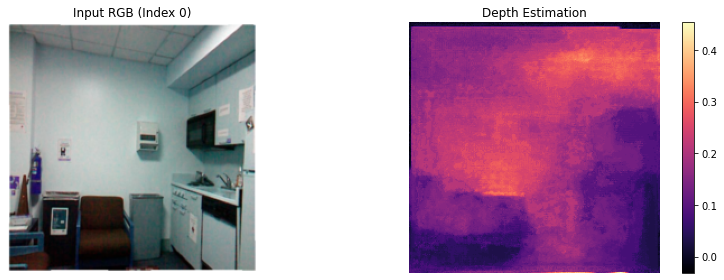

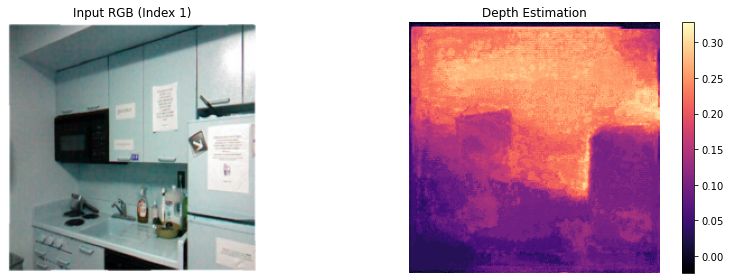

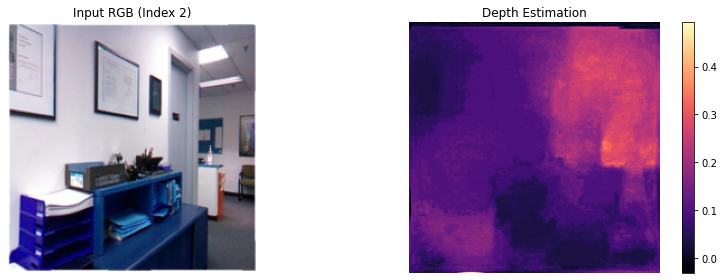

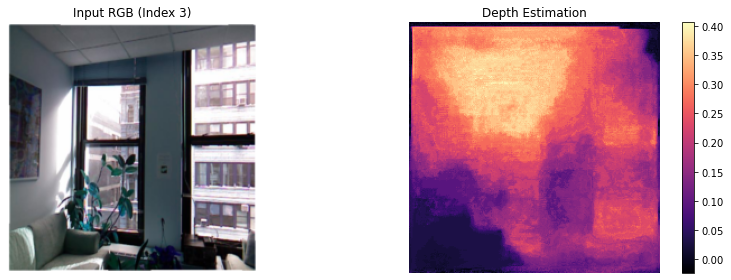

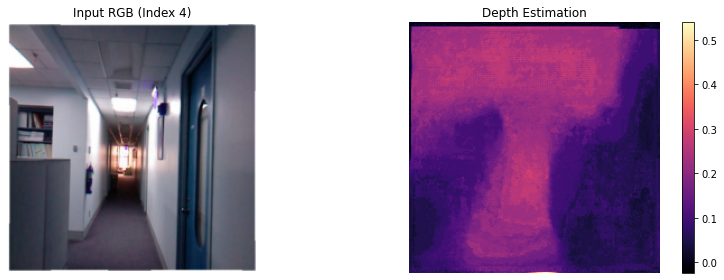

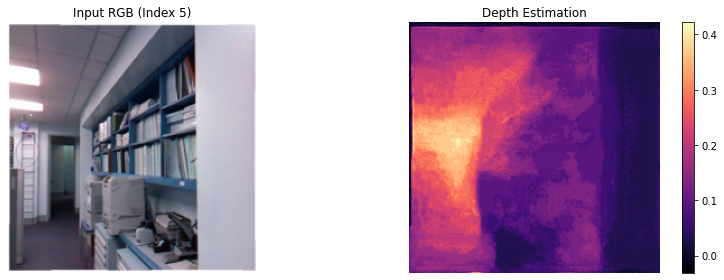

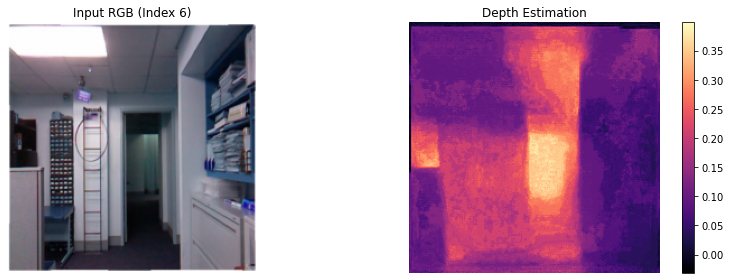

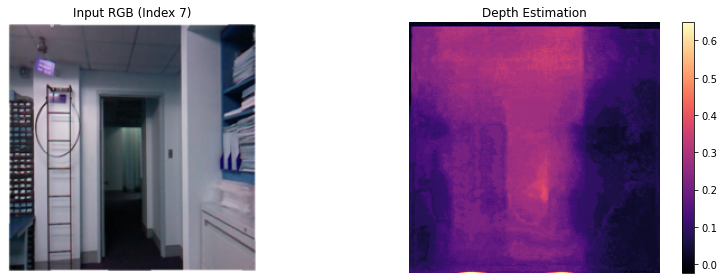

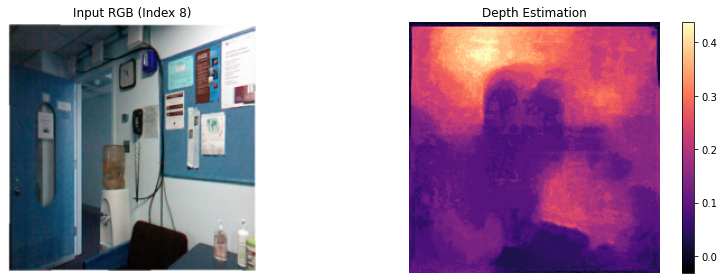

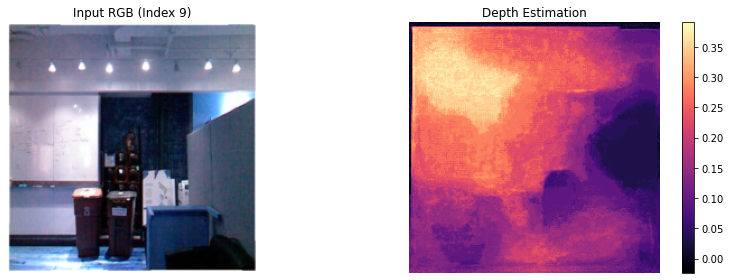

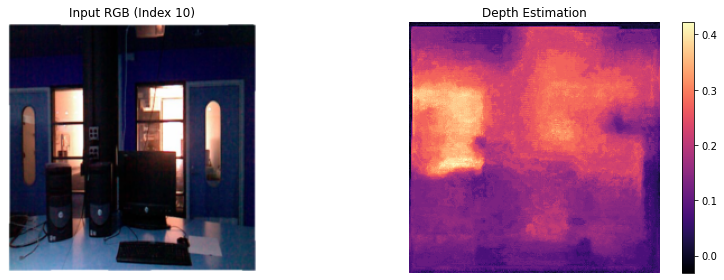

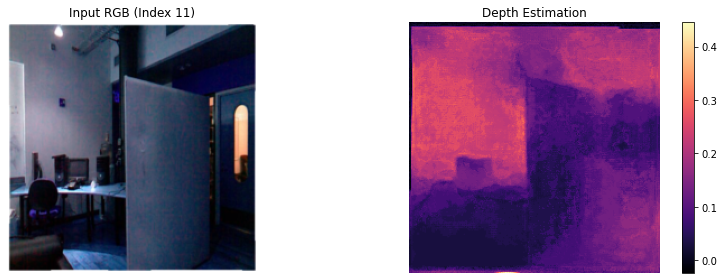

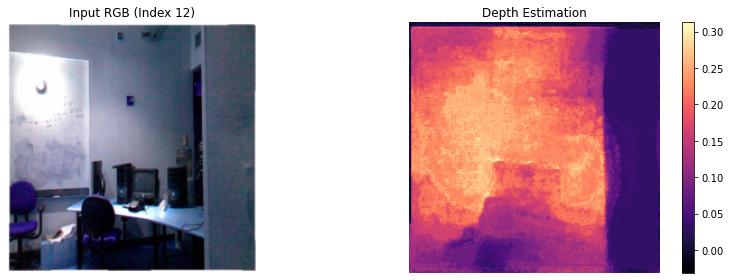

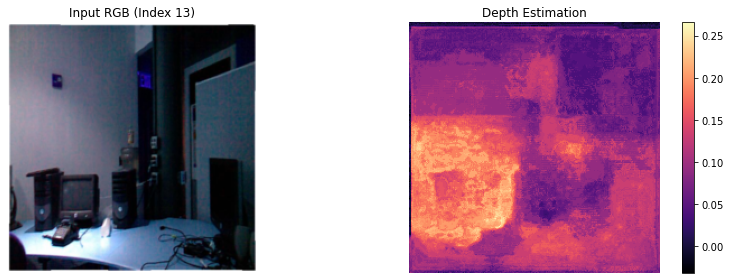

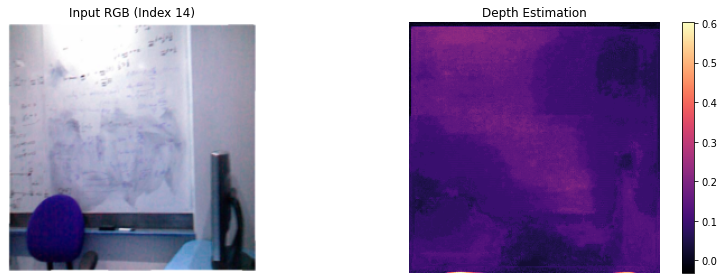

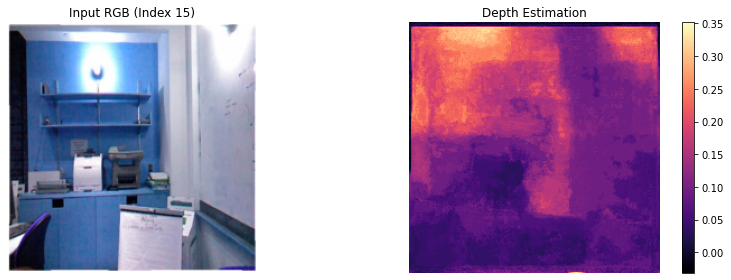

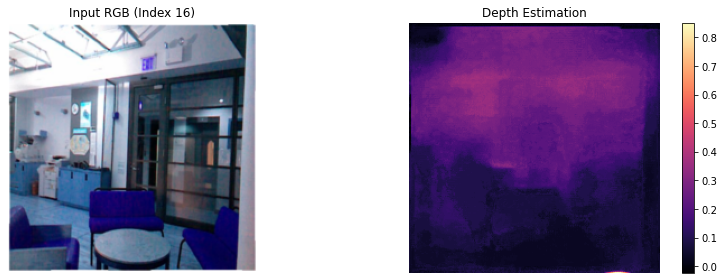

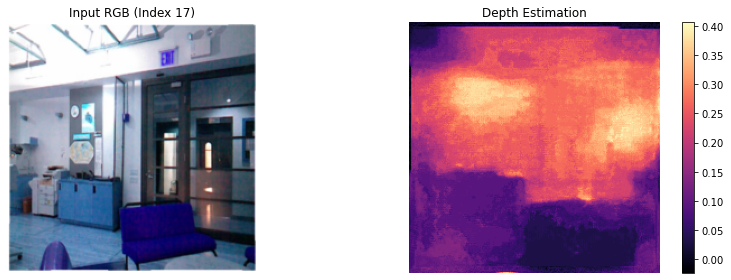

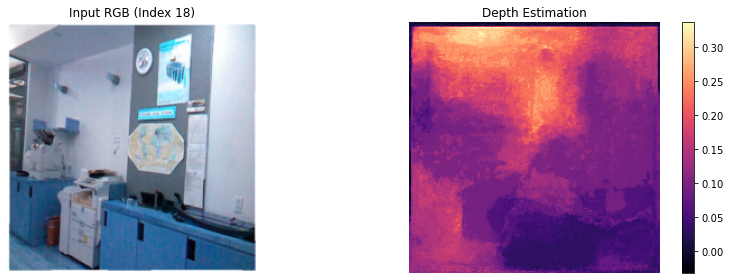

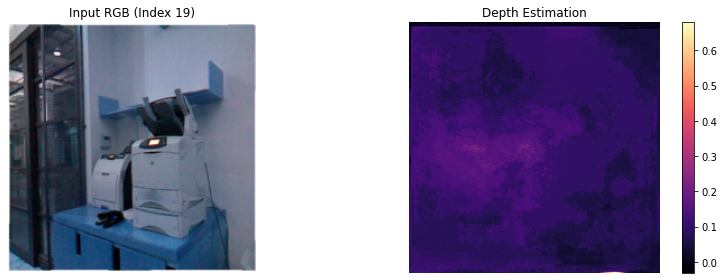

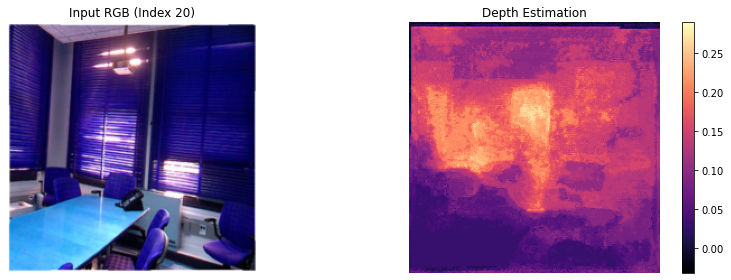

In [11]:
#idx = randint(0, len(test_data)-1)

for idx in range(len(test_data)):
    input_data[0][0,...] = test_data[idx]
    output_data[0][0,...] = test_label[idx]

    job_id = dpu.execute_async(input_data, output_data)
    dpu.wait(job_id)

    temp = [j.reshape(1, outputSize) for j in output_data]

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    ax[0].set_title(f"Input RGB (Index {idx})")
    ax[0].imshow(test_data[idx])
    ax[0].axis('off')

    ax[1].set_title("Depth Estimation")
    predicted_depth = output_data[0].squeeze()


    depth_plot = ax[1].imshow(predicted_depth, cmap='magma')
    ax[1].axis('off')

    fig.colorbar(depth_plot, ax=ax[1], orientation='vertical')

    plt.tight_layout()
    plt.show()

In [8]:
# --- DIAGNOSTIC ---
inputTensors = dpu.get_input_tensors()
outputTensors = dpu.get_output_tensors()

for t in inputTensors:
    print("INPUT  :", t.name, t.dims, t.dtype if hasattr(t, 'dtype') else '?')
for t in outputTensors:
    print("OUTPUT :", t.name, t.dims, t.dtype if hasattr(t, 'dtype') else '?')

print("test_data dtype/shape :", test_data.dtype, test_data.shape)
print("test_data[idx] min/max :", test_data[idx].min(), test_data[idx].max())
print("input_data[0] dtype/shape :", input_data[0].dtype, input_data[0].shape)

# Après exécution :
print("output_data[0] dtype/shape :", output_data[0].dtype, output_data[0].shape)
print("output_data[0] min/max/mean :", output_data[0].min(), output_data[0].max(), output_data[0].mean())

# Si le tensor de sortie est quantizé (int8), regarde son fixpos / scale :
out_tensor = outputTensors[0]
if hasattr(out_tensor, 'get_attr'):
    try:
        fixpos = out_tensor.get_attr("fix_point")
        scale = 1 / (2 ** fixpos)
        print("fix_point :", fixpos, "-> scale :", scale)
    except Exception as e:
        print("Pas de fix_point trouvé :", e)

INPUT  : UNet__input_0_fix [1, 224, 224, 3] xint8
OUTPUT : UNet__UNet_OutConv_outc__Conv2d_conv__510_fix [1, 224, 224, 1] xint8
test_data dtype/shape : float64 (21, 224, 224, 3)
test_data[idx] min/max : 0.0 1.0
input_data[0] dtype/shape : float32 (1, 224, 224, 3)
output_data[0] dtype/shape : float32 (1, 224, 224, 1)
output_data[0] min/max/mean : -0.03125 0.2890625 0.11641662
fix_point : 7 -> scale : 0.0078125
